   Años__ESTANDAR  value  grupo_etario_ord  cluster_gmm
0            2016     76                 0           11
1            2017     76                 0           11
2            2018     79                 0           11
3            2019     79                 0           11
4            2020     88                 0           11
Silhouette Score: 0.6377766716735552


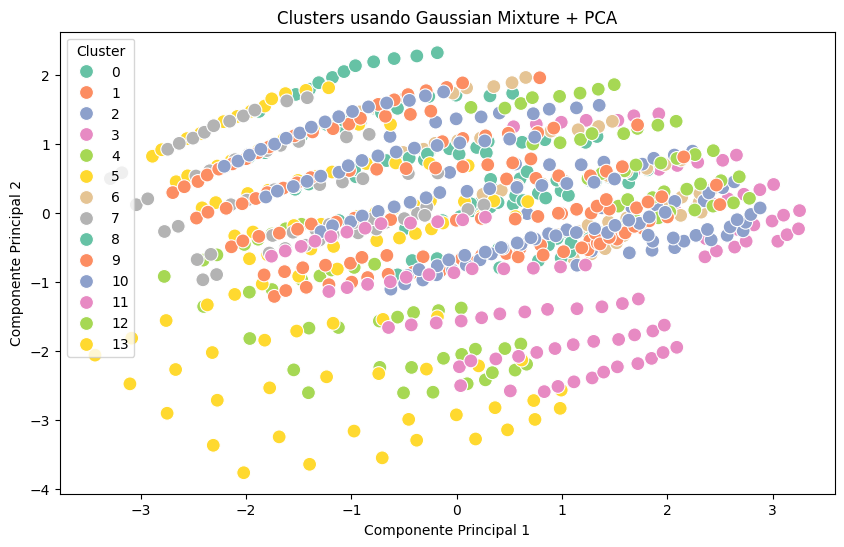

In [63]:
#SE DEBE CORRER PREVIAMENTE `pip install prophet` 
import pandas as pd
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns



#kmeans(M) ; gaussian mixture(R) ; OPTICS(M) ; agglomerative(R) 

# Leer datos
df = pd.read_csv("datos_transformados.csv")
X_GENERAL = df.drop(columns=["Grupos etarios Uso Internet"])    #porque ya está como ordinal en otra columna


############## GAUSSIAN MIXTURE
gaussian_scaler = StandardScaler()
X_escalado_Gauss = gaussian_scaler.fit_transform(X_GENERAL)

gmm = GaussianMixture(
    n_components=14,                   #con prueba y error, se encontró que el mejor silhouette score daba era con 14, pero se puede analizar en la siguiente semana si existe otro (o cambiando el covariancetype u otro parámetro)
    covariance_type='full',
    random_state=42
)
gmm.fit(X_escalado_Gauss)

clusters_gauss = gmm.predict(X_escalado_Gauss)
df["cluster_gmm"] = clusters_gauss

print(df[[
    "Años__ESTANDAR",
    "value",
    "grupo_etario_ord",
    "cluster_gmm"
]].head())


score = silhouette_score(X_escalado_Gauss, clusters_gauss)
print("Silhouette Score:", score)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado_Gauss)
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_gauss,
    palette='Set2',
    s=100
)
plt.title("Clusters usando Gaussian Mixture + PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()




Silhouette Score: 0.6377766716735552
[(3, 0.1320358404175487), (4, 0.17241355395792488), (5, 0.20663509916562267), (6, 0.2575308653218743), (7, 0.3103105577147512), (8, 0.3670751619672385), (9, 0.41607719774629437), (10, 0.46434467248442357), (11, 0.5078666240195744), (12, 0.5519653252491782), (13, 0.5941447944982988), (14, 0.6377766716735552), (15, 0.6092101533499794), (16, 0.5888639090213453), (17, 0.5768052902154447), (18, 0.5657418772301492), (19, 0.5518940056929283), (20, 0.5382499841377952), (21, 0.5332312222780748), (22, 0.5232498558967089), (23, 0.5101323639966537), (24, 0.49912520275646516)]


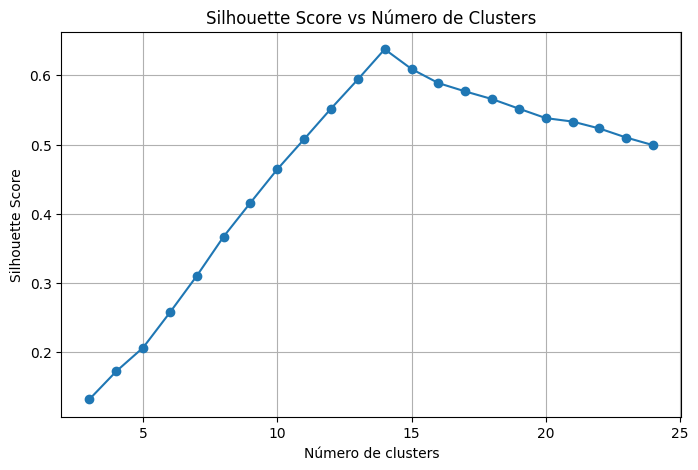

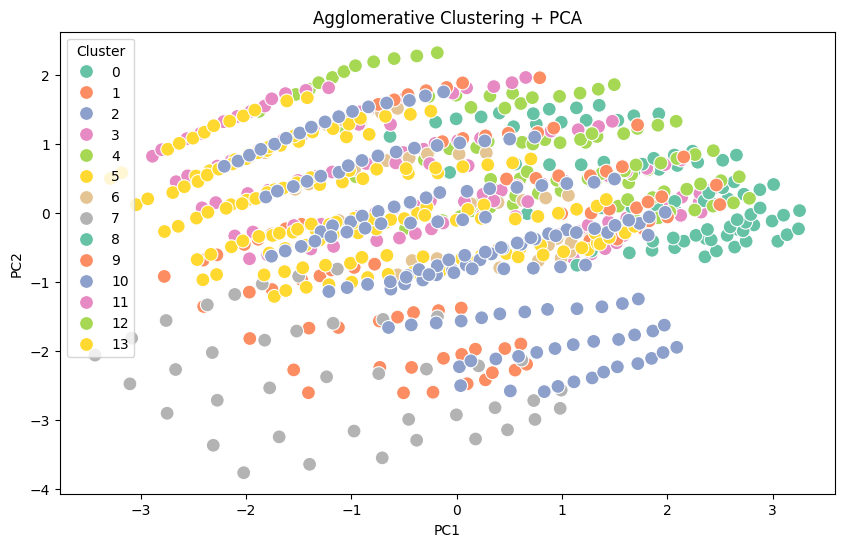

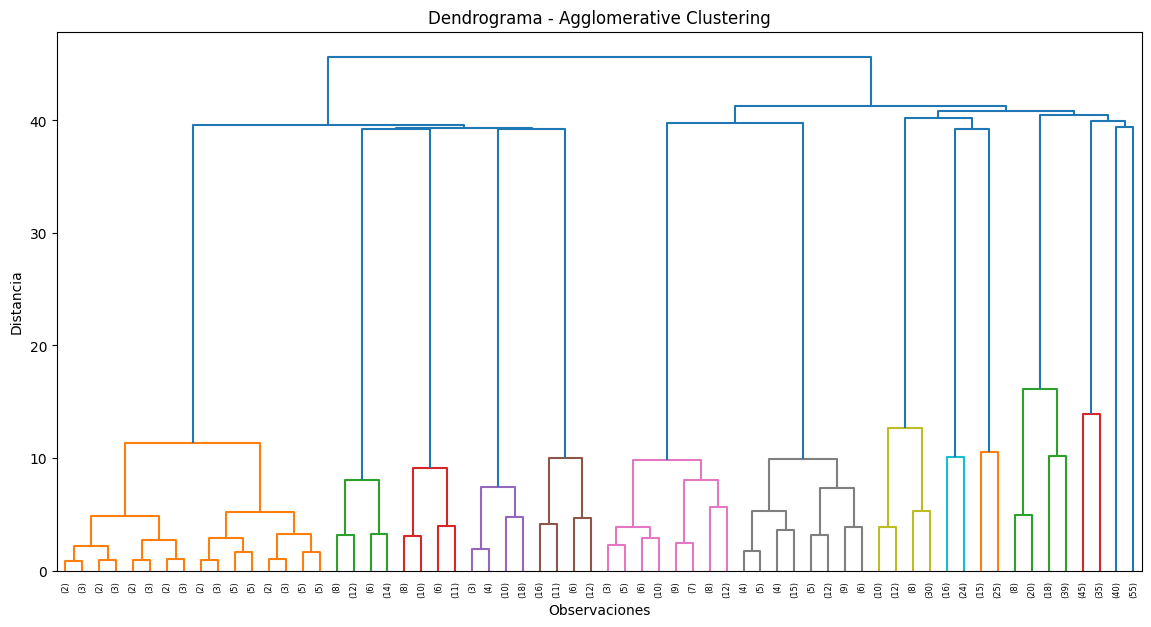

In [ ]:
#####AGGLOMERATIVE CLUSTERING
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram


agglomerative_scaler = StandardScaler()
X_escalado_agglo = agglomerative_scaler.fit_transform(X_GENERAL)

agg = AgglomerativeClustering(
    n_clusters=14,       #nuevamente, quedó 14
    linkage='ward'           ##PROBAR CON OTROS PARÁMETROS EN SEMANA 4
)

clusters_agglo = agg.fit_predict(X_escalado_agglo)
df["cluster_agg"] = clusters_agglo
score = silhouette_score(X_escalado_agglo, clusters_agglo)
print("Silhouette Score:", score)


scores = []
for k in range(3, 25):
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'          ##PROBAR CON OTROS PARÁMETROS EN SEMANA 4
    )
    labels = agg.fit_predict(X_escalado_agglo)
    score = silhouette_score(X_escalado_agglo, labels)
    scores.append((k, score))
print(scores)           #el mejor es 14, nuevamente

##graficar silhouette vs k
ks = [x[0] for x in scores]
vals = [x[1] for x in scores]
plt.figure(figsize=(8,5))
plt.plot(ks, vals, marker='o')
plt.title("Silhouette Score vs Número de Clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

#### scatter de los clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado_agglo)
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_agglo,
    palette='Set2',
    s=100
)
plt.title("Agglomerative Clustering + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


#### dendograma
linked = linkage(X_escalado_agglo, method='ward')
plt.figure(figsize=(14,7))
dendrogram(
    linked,
    truncate_mode='level',
    p=5
)
plt.title("Dendrograma - Agglomerative Clustering")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()


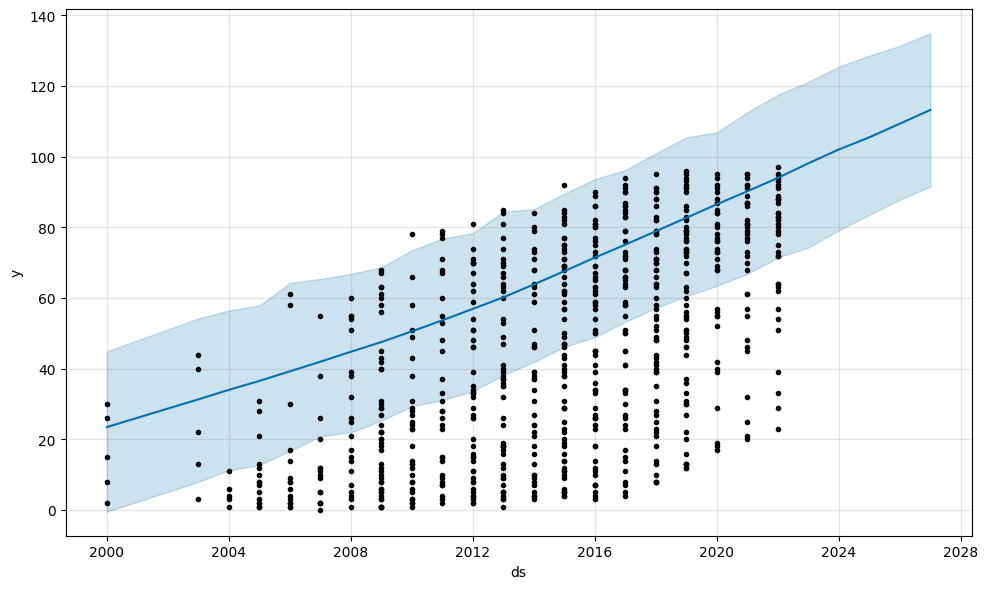

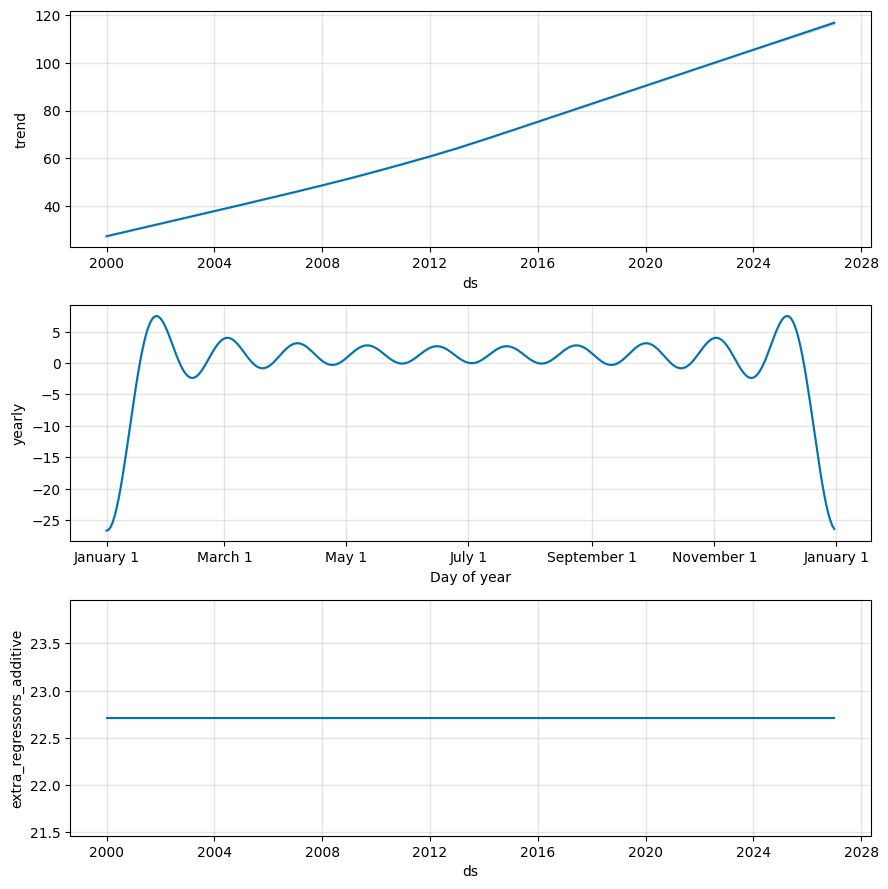

In [ ]:


# Renombrar columnas
df = df.rename(columns={
    "Años__ESTANDAR": "ds",
    "value": "y"
})

# Fecha
df["ds"] = pd.to_datetime(df["ds"], format="%Y")

# Crear modelo
model = Prophet()

# Regresor extra
model.add_regressor("grupo_etario_ord")

# Entrenar
model.fit(df[["ds", "y", "grupo_etario_ord"]])

# Futuro
future = model.make_future_dataframe(periods=5, freq='Y')

# Necesitas también valores del regresor
future["grupo_etario_ord"] = 0

# Predicción
forecast = model.predict(future)

print(forecast[["ds", "yhat"]].tail())
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

